<a href="https://colab.research.google.com/github/KartikMantri/U-Kan-repo/blob/main/UKAN_REFUGE_3class_Kaggle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# U-KAN — 3-Class Optic Disc & Cup Segmentation on REFUGE (Kaggle-ready)

**Goal:** push mean Dice (Disc + Cup) toward / past **0.90**.

This notebook is the official U-KAN architecture (3 KANLinear sublayers + DW_bn_relu)
trained for **3-class** segmentation (background / optic disc / optic cup) on the
REFUGE dataset, with every improvement discussed baked in:

- **Ground-truth masks taken from the REFUGE dataset itself** (auto-detected encoding, remapped to 0=bg,1=disc,2=cup)
- **Loss = CrossEntropy + Dice + Focal-Tversky** (Focal-Tversky penalises false-negatives harder → fixes cup under-segmentation)
- **Higher resolution (384²)** — a key lever for the tiny cup class
- **Stronger augmentations** (geometric + photometric + CLAHE)
- **Test-Time Augmentation (TTA)** at inference
- **Anatomical post-processing** (largest-component + enforce *cup ⊆ disc*)
- **Full metric suite** you used before: Dice, IoU, Precision, Recall, F1, Accuracy (+ HD95)
- **All visualizations**: augmented samples, 6-panel training curves, qualitative predictions

### How to run on Kaggle
1. **+ Add Data** → search **`glaucoma-datasets`** (by *arnavjain1*) → Add.
2. Settings → **Accelerator = GPU (P100 or T4)**, **Internet = On** (only needed if albumentations must install).
3. **Run All**. Trained weights + metrics are saved to `/kaggle/working/`.

> If your dataset paths differ, only **CELL 2 (CONFIG)** needs editing — everything else auto-adapts.


In [8]:
# ==== CELL 1 — Environment setup & imports ====
import os, sys, glob, math, random, time, warnings, json
warnings.filterwarnings("ignore")

import numpy as np
import cv2
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

# Albumentations = fast image+mask augmentation. Pre-installed on Kaggle; install if missing.
try:
    import albumentations as A
    from albumentations.pytorch import ToTensorV2
except Exception:
    os.system("pip install -q albumentations")
    import albumentations as A
    from albumentations.pytorch import ToTensorV2

from scipy import ndimage  # connected components + hole filling for post-processing

# ---- Reproducibility: fix every RNG so runs are comparable ----
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Torch:", torch.__version__, "| Albumentations:", A.__version__, "| Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Torch: 2.11.0+cu128 | Albumentations: 2.0.8 | Device: cuda
GPU: Tesla T4


In [7]:
# Download the bundle (contains G1020, ORIGA, REFUGE) — Google Colab
!pip install -q kaggle
from google.colab import files
files.upload()                        # <- upload your kaggle.json here
!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d arnavjain1/glaucoma-datasets -p /content/data --unzip
!ls /content/data                     # you should see: G1020  ORIGA  REFUGE
!ls /content/data/REFUGE              # look at REFUGE's folder names
os.system("kaggle datasets download -d arnavjain1/glaucoma-datasets -p /content/glaucoma-datasets --unzip")

Saving kaggle.json to kaggle (1).json
Dataset URL: https://www.kaggle.com/datasets/arnavjain1/glaucoma-datasets
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
100% 5.55G/5.55G [04:22<00:00, 22.7MB/s]

G1020  models  ORIGA  REFUGE
Images_Square  Masks_Square  test  train  val


0

In [12]:
import os, glob, random

REFUGE = "/content/data/REFUGE"
EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

def collect_variant(split_dir, keyword):
    """Collect (image, mask) pairs whose path contains `keyword`, matched by filename stem.
       Anything with 'mask' in its path is treated as a mask, everything else as an image."""
    imgs, msks = {}, {}
    for dp, _, fs in os.walk(split_dir):
        low = dp.lower()
        if keyword and keyword not in low:      # restrict to one variant (cropped/square)
            continue
        is_mask = "mask" in low
        for f in fs:
            if f.lower().endswith(EXTS):
                stem = os.path.splitext(f)[0]
                (msks if is_mask else imgs)[stem] = os.path.join(dp, f)
    return [(imgs[s], msks[s]) for s in imgs if s in msks]

def collect(split_dir):
    # prefer cropped ROI (best for cup Dice); fall back to square, then anything
    for kw in ("crop", "square", ""):
        pairs = collect_variant(split_dir, kw)
        if pairs:
            return pairs, kw
    return [], None

split_pairs = {}
for sp in ["train", "val", "test"]:
    d = os.path.join(REFUGE, sp)
    pairs, kw = collect(d) if os.path.isdir(d) else ([], None)
    split_pairs[sp] = pairs
    ex = f"{os.path.basename(pairs[0][0])} <-> {os.path.basename(pairs[0][1])}" if pairs else "-"
    print(f"{sp:5s}: {len(pairs):4d} pairs (variant={kw})  e.g. {ex}")

# safety fallback: if the split folders yielded nothing, scan all of REFUGE and split 80/10/10
if sum(len(v) for v in split_pairs.values()) == 0:
    print("No pairs in train/val/test -> scanning all of REFUGE with an 80/10/10 split.")
    allp, _ = collect(REFUGE)
    random.Random(42).shuffle(allp)
    n = len(allp); ntr = int(0.8*n); nva = int(0.1*n)
    split_pairs = {"train": allp[:ntr], "val": allp[ntr:ntr+nva], "test": allp[ntr+nva:]}

print("\nsplit ->", {k: len(v) for k, v in split_pairs.items()})
assert len(split_pairs["train"]) > 0, "Still 0 — run:  !find /content/data/REFUGE -maxdepth 3 -type d  and paste it here."

train:  400 pairs (variant=crop)  e.g. g0010.jpg <-> g0010.png
val  :  400 pairs (variant=crop)  e.g. V0350.jpg <-> V0350.png
test :  400 pairs (variant=crop)  e.g. T0019.jpg <-> T0019.png

split -> {'train': 400, 'val': 400, 'test': 400}


In [15]:
!find /content/data/REFUGE -maxdepth 3 | head -60

/content/data/REFUGE
/content/data/REFUGE/Masks_Square
/content/data/REFUGE/Masks_Square/n0125.png
/content/data/REFUGE/Masks_Square/V0323.png
/content/data/REFUGE/Masks_Square/V0123.png
/content/data/REFUGE/Masks_Square/n0248.png
/content/data/REFUGE/Masks_Square/V0043.png
/content/data/REFUGE/Masks_Square/n0049.png
/content/data/REFUGE/Masks_Square/T0201.png
/content/data/REFUGE/Masks_Square/n0353.png
/content/data/REFUGE/Masks_Square/T0096.png
/content/data/REFUGE/Masks_Square/V0054.png
/content/data/REFUGE/Masks_Square/V0306.png
/content/data/REFUGE/Masks_Square/T0325.png
/content/data/REFUGE/Masks_Square/T0145.png
/content/data/REFUGE/Masks_Square/T0047.png
/content/data/REFUGE/Masks_Square/T0097.png
/content/data/REFUGE/Masks_Square/V0291.png
/content/data/REFUGE/Masks_Square/V0059.png
/content/data/REFUGE/Masks_Square/n0327.png
/content/data/REFUGE/Masks_Square/T0016.png
/content/data/REFUGE/Masks_Square/V0016.png
/content/data/REFUGE/Masks_Square/n0133.png
/content/data/REFUGE/

In [16]:
# ================= CELL 3 — Build REFUGE pairs (official g/n/V/T prefix split) =================
# REFUGE stores everything flat:
#   images -> /content/data/REFUGE/Images_Square/*.jpg
#   masks  -> /content/data/REFUGE/Masks_Square/*.png   (same filename stem)
# Official split is encoded in the filename prefix:
#   g#### , n####  -> TRAIN (400)   |   V#### -> VAL (400)   |   T#### -> TEST (400)
REFUGE   = "/content/data/REFUGE"
IMG_DIR  = os.path.join(REFUGE, "Images_Square")
MASK_DIR = os.path.join(REFUGE, "Masks_Square")

EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")
def list_imgs(d):
    fs = []
    for e in EXTS:
        fs += glob.glob(os.path.join(d, "*" + e))
    return sorted(fs)

# match each image to its mask by filename stem
masks = {os.path.splitext(os.path.basename(p))[0]: p for p in list_imgs(MASK_DIR)}
pairs = [(ip, masks[os.path.splitext(os.path.basename(ip))[0]])
         for ip in list_imgs(IMG_DIR)
         if os.path.splitext(os.path.basename(ip))[0] in masks]
print("images found:", len(list_imgs(IMG_DIR)),
      "| masks found:", len(list_imgs(MASK_DIR)),
      "| matched pairs:", len(pairs))

# official split from the filename prefix
def which(img_path):
    c = os.path.basename(img_path)[0].lower()
    return "val" if c == "v" else "test" if c == "t" else "train"   # g / n -> train

split_pairs = {"train": [], "val": [], "test": []}
for ip, mp in pairs:
    split_pairs[which(ip)].append((ip, mp))

print("split ->", {k: len(v) for k, v in split_pairs.items()})
assert len(split_pairs["train"]) > 0, (
    "0 pairs — check that /content/data/REFUGE/Images_Square has images. "
    "Run:  !ls /content/data/REFUGE/Images_Square | head")

images found: 1200 | masks found: 1200 | matched pairs: 1200
split -> {'train': 400, 'val': 400, 'test': 400}


In [17]:
# ==== CELL 4 — Detect mask encoding & remap to {0:bg, 1:disc, 2:cup} ====
# REFUGE masks come in two common encodings:
#   (A) class indices  [0,1,2]                       -> use as-is
#   (B) original grayscale [0,128,255]:  0=cup, 128=disc, 255=background
# We look at real pixel values and build one remap that always outputs 0=bg,1=disc,2=cup.

def _read_gray(path):
    m = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    if m is None: return None
    if m.ndim == 3: m = m[..., 0]
    return m

def sample_unique_values(pairs, k=40):
    vals = set()
    for _, mp in pairs[:k]:
        m = _read_gray(mp)
        if m is not None: vals |= set(np.unique(m).tolist())
    return sorted(vals)

uvals = sample_unique_values(split_pairs["train"])
print("Sampled unique mask pixel values:", uvals)

def remap_mask(m):
    """Return a HxW uint8 mask with values in {0=bg, 1=disc, 2=cup}."""
    if m.ndim == 3: m = m[..., 0]
    u = set(np.unique(m).tolist())
    out = np.zeros(m.shape, dtype=np.uint8)
    if u <= {0, 1, 2}:                       # (A) already class indices
        out = m.astype(np.uint8)
    elif u <= {0, 128, 255} or 128 in u:     # (B) original REFUGE grayscale
        out[m == 255] = 0                    # background
        out[(m > 0) & (m < 255)] = 1         # disc (128)
        out[m == 0] = 2                      # cup
    else:                                    # generic 3-level fallback: dark=cup, mid=disc, bright=bg
        thr = sorted(u)
        out[m >= thr[-1]] = 0
        if len(thr) >= 3: out[(m > thr[0]) & (m < thr[-1])] = 1
        out[m <= thr[0]] = 2
    return out

# quick check on one sample
_m = remap_mask(_read_gray(split_pairs["train"][0][1]))
print("After remap unique values:", np.unique(_m).tolist(),
      "| pixel share bg/disc/cup:",
      [round((_m==c).mean(),3) for c in (0,1,2)])


Sampled unique mask pixel values: [0, 1, 2]
After remap unique values: [0, 1, 2] | pixel share bg/disc/cup: [np.float64(0.98), np.float64(0.012), np.float64(0.008)]


In [18]:
# ==== CELL 5 — Augmentations & preprocessing ====
# TRAIN: geometric (flip/shift/scale/rotate) + photometric (brightness/contrast/CLAHE/hue)
#        variety makes the cup boundary robust across cameras & illumination.
#        CLAHE boosts local contrast at the disc/cup rim — the hardest region.
# VAL/TEST: only resize + normalize (deterministic, no randomness).
# We keep to transforms whose signatures are stable across albumentations versions,
# and fall back gracefully if a version rejects a kwarg.
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)
S = cfg.IMG_SIZE

def build_train_tf(S):
    core = [
        A.Resize(S, S),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.3),
        A.ShiftScaleRotate(shift_limit=0.06, scale_limit=0.10, rotate_limit=25,
                           border_mode=cv2.BORDER_CONSTANT, p=0.6),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
        A.CLAHE(clip_limit=2.0, p=0.3),
        A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=15, val_shift_limit=10, p=0.3),
    ]
    tail = [A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD), ToTensorV2()]
    # try to add elastic-style distortion + noise; skip if the installed version differs
    try:
        extra = [A.OneOf([A.GridDistortion(num_steps=5, distort_limit=0.2),
                          A.OpticalDistortion(distort_limit=0.2)], p=0.25),
                 A.GaussNoise(p=0.2)]
        tf = A.Compose(core + extra + tail)
    except Exception as e:
        print("[aug] using core-only pipeline:", e)
        tf = A.Compose(core + tail)
    return tf

train_tf = build_train_tf(S)
val_tf   = A.Compose([A.Resize(S, S), A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD), ToTensorV2()])
print("Augmentation pipeline ready. Train transforms:", len(train_tf.transforms))


Augmentation pipeline ready. Train transforms: 11


In [19]:
# ==== CELL 6 — Dataset class ====
# Reads an image (BGR->RGB), reads its mask, remaps mask to {0,1,2}, applies the
# transform (albumentations keeps mask aligned with image and uses nearest-neighbour
# on the mask so class integers are never blended).
class REFUGEDataset(Dataset):
    def __init__(self, pairs, transform):
        self.pairs = pairs
        self.transform = transform
    def __len__(self):
        return len(self.pairs)
    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]
        image = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        mask  = remap_mask(cv2.imread(mask_path, cv2.IMREAD_UNCHANGED))
        aug = self.transform(image=image, mask=mask)
        return aug["image"], aug["mask"].long()


Batch image: (8, 3, 384, 384) | mask: (8, 384, 384) | mask classes present: [0, 1, 2]


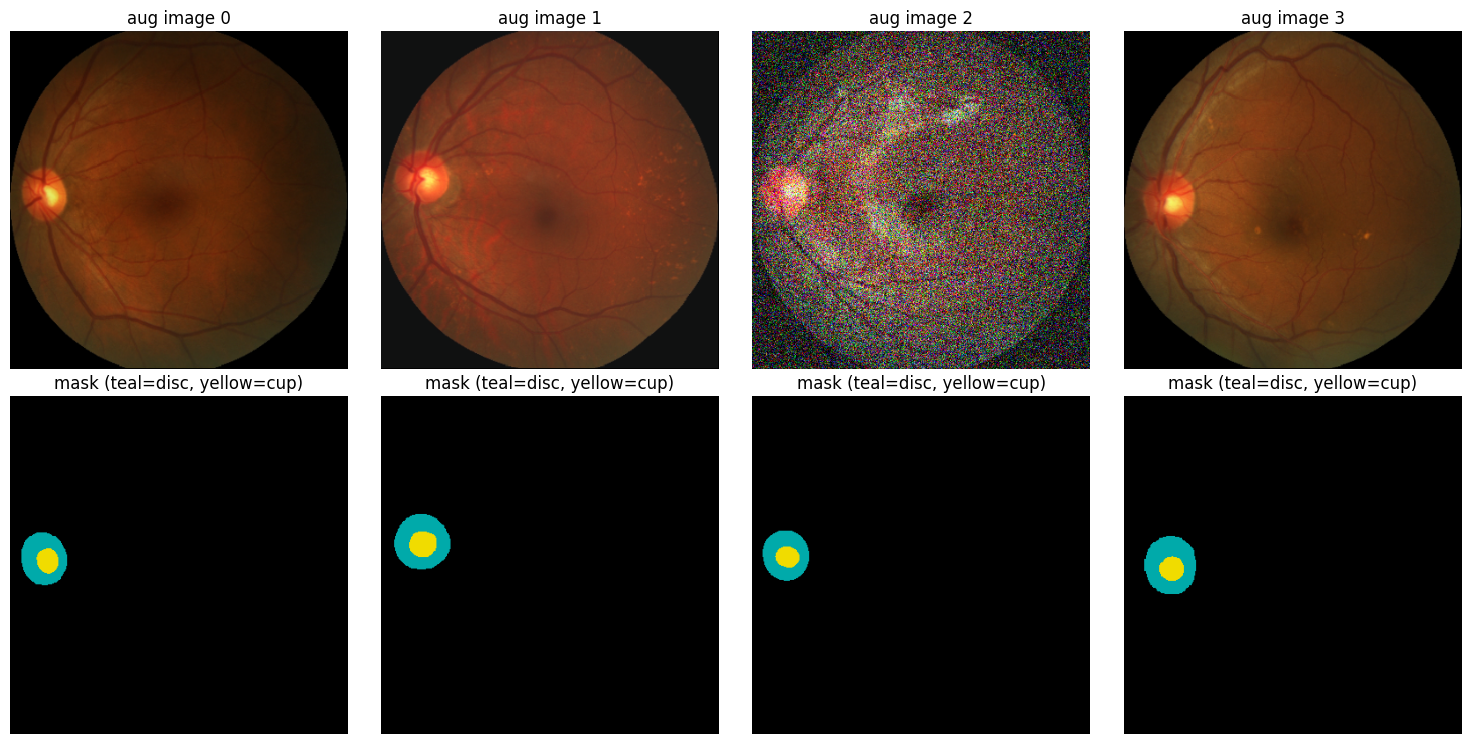

In [20]:
# ==== CELL 7 — DataLoaders + sanity check + visualize augmented samples ====
train_ds = REFUGEDataset(split_pairs["train"], train_tf)
val_ds   = REFUGEDataset(split_pairs["val"],   val_tf)
test_ds  = REFUGEDataset(split_pairs["test"],  val_tf)

train_loader = DataLoader(train_ds, batch_size=cfg.BATCH_SIZE, shuffle=True,
                          num_workers=cfg.NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=cfg.BATCH_SIZE, shuffle=False,
                          num_workers=cfg.NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=cfg.BATCH_SIZE, shuffle=False,
                          num_workers=cfg.NUM_WORKERS, pin_memory=True)

xb, yb = next(iter(train_loader))
print("Batch image:", tuple(xb.shape), "| mask:", tuple(yb.shape),
      "| mask classes present:", torch.unique(yb).tolist())

def denorm(t):
    """Undo ImageNet normalization for display."""
    img = t.permute(1,2,0).cpu().numpy()
    img = img*np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    return np.clip(img, 0, 1)

# colour map for masks: bg=black, disc=teal, cup=yellow
CMAP = np.array([[0,0,0],[0,170,170],[240,220,0]], dtype=np.uint8)
def colorize(mask):
    return CMAP[mask]

fig, ax = plt.subplots(2, 4, figsize=(15, 7.5))
for j in range(4):
    ax[0,j].imshow(denorm(xb[j])); ax[0,j].set_title(f"aug image {j}"); ax[0,j].axis("off")
    ax[1,j].imshow(colorize(yb[j].cpu().numpy())); ax[1,j].set_title("mask (teal=disc, yellow=cup)"); ax[1,j].axis("off")
plt.tight_layout(); plt.show()


In [21]:
# ==== CELL 8 — KAN building blocks (official efficient-KAN math) ====
# KANLinear: every connection is a learnable 1-D function = base(SiLU) path + cubic B-spline path.
# This is the exact efficient-kan implementation used by the official U-KAN repo.
class KANLinear(nn.Module):
    def __init__(self, in_features, out_features, grid_size=5, spline_order=3,
                 scale_noise=0.1, scale_base=1.0, scale_spline=1.0,
                 enable_standalone_scale_spline=True,
                 base_activation=nn.SiLU, grid_range=[-1, 1]):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.grid_size = grid_size
        self.spline_order = spline_order
        h = (grid_range[1] - grid_range[0]) / grid_size
        grid = ((torch.arange(-spline_order, grid_size + spline_order + 1) * h + grid_range[0])
                .expand(in_features, -1).contiguous())
        self.register_buffer("grid", grid)                                   # knot positions
        self.base_weight   = nn.Parameter(torch.Tensor(out_features, in_features))
        self.spline_weight = nn.Parameter(torch.Tensor(out_features, in_features, grid_size + spline_order))
        self.enable_standalone_scale_spline = enable_standalone_scale_spline
        if enable_standalone_scale_spline:
            self.spline_scaler = nn.Parameter(torch.Tensor(out_features, in_features))
        self.scale_noise = scale_noise; self.scale_base = scale_base; self.scale_spline = scale_spline
        self.base_activation = base_activation()
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.kaiming_uniform_(self.base_weight, a=math.sqrt(5) * self.scale_base)
        with torch.no_grad():
            noise = ((torch.rand(self.grid_size + 1, self.in_features, self.out_features) - 0.5)
                     * self.scale_noise / self.grid_size)
            self.spline_weight.data.copy_(
                (self.scale_spline if not self.enable_standalone_scale_spline else 1.0)
                * self.curve2coeff(self.grid.T[self.spline_order:-self.spline_order], noise))
            if self.enable_standalone_scale_spline:
                nn.init.kaiming_uniform_(self.spline_scaler, a=math.sqrt(5) * self.scale_spline)

    def b_splines(self, x):
        # x: (..., in_features) -> B-spline bases via Cox-de Boor recursion
        grid = self.grid
        x = x.unsqueeze(-1)
        bases = ((x >= grid[:, :-1]) & (x < grid[:, 1:])).to(x.dtype)
        for k in range(1, self.spline_order + 1):
            bases = ((x - grid[:, :-(k+1)]) / (grid[:, k:-1] - grid[:, :-(k+1)]) * bases[:, :, :-1]) \
                  + ((grid[:, k+1:] - x) / (grid[:, k+1:] - grid[:, 1:(-k)]) * bases[:, :, 1:])
        return bases.contiguous()

    def curve2coeff(self, x, y):
        A = self.b_splines(x).transpose(0, 1)            # (in, n_samples, coeff)
        B = y.transpose(0, 1)                            # (in, n_samples, out)
        solution = torch.linalg.lstsq(A, B).solution     # (in, coeff, out)
        return solution.permute(2, 0, 1).contiguous()    # (out, in, coeff)

    @property
    def scaled_spline_weight(self):
        s = self.spline_scaler.unsqueeze(-1) if self.enable_standalone_scale_spline else 1.0
        return self.spline_weight * s

    def forward(self, x):
        orig = x.shape
        x = x.reshape(-1, self.in_features)
        base_out   = F.linear(self.base_activation(x), self.base_weight)
        spline_out = F.linear(self.b_splines(x).view(x.size(0), -1),
                              self.scaled_spline_weight.view(self.out_features, -1))
        return (base_out + spline_out).reshape(*orig[:-1], self.out_features)


class DW_bn_relu(nn.Module):
    """Depthwise 3x3 conv + BatchNorm + ReLU: injects local spatial context between KAN layers."""
    def __init__(self, dim):
        super().__init__()
        self.dwconv = nn.Conv2d(dim, dim, 3, 1, 1, bias=True, groups=dim)
        self.bn = nn.BatchNorm2d(dim)
        self.relu = nn.ReLU()
    def forward(self, x, H, W):
        B, N, C = x.shape
        x = x.transpose(1, 2).view(B, C, H, W)
        x = self.relu(self.bn(self.dwconv(x)))
        return x.flatten(2).transpose(1, 2)


class KANLayer(nn.Module):
    """3 KANLinear sublayers, each followed by DW_bn_relu — the official 3-sublayer block."""
    def __init__(self, in_features, hidden_features=None, out_features=None, no_kan=False):
        super().__init__()
        hidden_features = hidden_features or in_features
        out_features = out_features or in_features
        self.fc1 = KANLinear(in_features, hidden_features)
        self.fc2 = KANLinear(hidden_features, out_features)
        self.fc3 = KANLinear(hidden_features, out_features)
        self.dwconv_1 = DW_bn_relu(hidden_features)
        self.dwconv_2 = DW_bn_relu(hidden_features)
        self.dwconv_3 = DW_bn_relu(hidden_features)
    def forward(self, x, H, W):
        B, N, C = x.shape
        x = self.dwconv_1(self.fc1(x.reshape(B*N, C)).reshape(B, N, C), H, W)
        x = self.dwconv_2(self.fc2(x.reshape(B*N, C)).reshape(B, N, C), H, W)
        x = self.dwconv_3(self.fc3(x.reshape(B*N, C)).reshape(B, N, C), H, W)
        return x


def drop_path(x, drop_prob: float = 0., training: bool = False):
    if drop_prob == 0. or not training: return x
    keep = 1 - drop_prob
    shape = (x.shape[0],) + (1,) * (x.ndim - 1)
    rnd = keep + torch.rand(shape, dtype=x.dtype, device=x.device)
    return x.div(keep) * rnd.floor()

class DropPath(nn.Module):
    def __init__(self, drop_prob=None):
        super().__init__(); self.drop_prob = drop_prob
    def forward(self, x): return drop_path(x, self.drop_prob, self.training)


class KANBlock(nn.Module):
    """Residual wrapper: x + DropPath(KANLayer(LayerNorm(x)))."""
    def __init__(self, dim, drop_path_p=0., norm_layer=nn.LayerNorm, no_kan=False):
        super().__init__()
        self.norm2 = norm_layer(dim)
        self.drop_path = DropPath(drop_path_p) if drop_path_p > 0. else nn.Identity()
        self.layer = KANLayer(in_features=dim, hidden_features=dim)
    def forward(self, x, H, W):
        return x + self.drop_path(self.layer(self.norm2(x), H, W))

print("KAN blocks defined.")


KAN blocks defined.


In [22]:
# ==== CELL 9 — Full U-KAN model (encoder-conv -> KAN bottleneck -> decoder-conv) ====
def to_2tuple(x): return (x, x) if isinstance(x, int) else x

class ConvLayer(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True))
    def forward(self, x): return self.conv(x)

class D_ConvLayer(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, in_ch, 3, padding=1), nn.BatchNorm2d(in_ch), nn.ReLU(inplace=True),
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True))
    def forward(self, x): return self.conv(x)

class PatchEmbed(nn.Module):
    """Overlapping patch embedding via a stride-2 conv; returns tokens + spatial (H,W)."""
    def __init__(self, img_size=224, patch_size=3, stride=2, in_chans=3, embed_dim=768):
        super().__init__()
        patch_size = to_2tuple(patch_size)
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=stride,
                              padding=(patch_size[0]//2, patch_size[1]//2))
        self.norm = nn.LayerNorm(embed_dim)
    def forward(self, x):
        x = self.proj(x)
        _, _, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)
        x = self.norm(x)
        return x, H, W

class UKAN(nn.Module):
    def __init__(self, num_classes=3, input_channels=3, img_size=256,
                 embed_dims=[256, 320, 512], drop_path_rate=0.0,
                 norm_layer=nn.LayerNorm, depths=[1, 1, 1]):
        super().__init__()
        d0 = embed_dims[0]
        # --- Convolutional encoder ---
        self.encoder1 = ConvLayer(input_channels, d0 // 8)   # 3   -> 32
        self.encoder2 = ConvLayer(d0 // 8, d0 // 4)          # 32  -> 64
        self.encoder3 = ConvLayer(d0 // 4, d0)               # 64  -> 256
        # --- Norms for KAN stages ---
        self.norm3  = norm_layer(embed_dims[1]); self.norm4  = norm_layer(embed_dims[2])
        self.dnorm3 = norm_layer(embed_dims[1]); self.dnorm4 = norm_layer(embed_dims[0])
        dpr = [x.item() for x in torch.linspace(0, drop_path_rate, sum(depths))]
        # --- KAN bottleneck (encoder side + decoder side) ---
        self.block1  = nn.ModuleList([KANBlock(embed_dims[1], dpr[0], norm_layer)])
        self.block2  = nn.ModuleList([KANBlock(embed_dims[2], dpr[1], norm_layer)])
        self.dblock1 = nn.ModuleList([KANBlock(embed_dims[1], dpr[0], norm_layer)])
        self.dblock2 = nn.ModuleList([KANBlock(embed_dims[0], dpr[1], norm_layer)])
        self.patch_embed3 = PatchEmbed(img_size // 4, 3, 2, embed_dims[0], embed_dims[1])
        self.patch_embed4 = PatchEmbed(img_size // 8, 3, 2, embed_dims[1], embed_dims[2])
        # --- Convolutional decoder ---
        self.decoder1 = D_ConvLayer(embed_dims[2], embed_dims[1])
        self.decoder2 = D_ConvLayer(embed_dims[1], embed_dims[0])
        self.decoder3 = D_ConvLayer(embed_dims[0], embed_dims[0] // 4)
        self.decoder4 = D_ConvLayer(embed_dims[0] // 4, embed_dims[0] // 8)
        self.decoder5 = D_ConvLayer(embed_dims[0] // 8, embed_dims[0] // 8)
        self.final = nn.Conv2d(embed_dims[0] // 8, num_classes, kernel_size=1)

    def forward(self, x):
        B = x.shape[0]
        # ----- conv encoder (each stage halves H,W) -----
        out = F.relu(F.max_pool2d(self.encoder1(x), 2, 2)); t1 = out   # H/2
        out = F.relu(F.max_pool2d(self.encoder2(out), 2, 2)); t2 = out  # H/4
        out = F.relu(F.max_pool2d(self.encoder3(out), 2, 2)); t3 = out  # H/8
        # ----- KAN stage 4 -----
        out, H, W = self.patch_embed3(out)
        for blk in self.block1: out = blk(out, H, W)
        out = self.norm3(out).reshape(B, H, W, -1).permute(0, 3, 1, 2).contiguous(); t4 = out
        # ----- KAN bottleneck -----
        out, H, W = self.patch_embed4(out)
        for blk in self.block2: out = blk(out, H, W)
        out = self.norm4(out).reshape(B, H, W, -1).permute(0, 3, 1, 2).contiguous()
        # ----- KAN decoder 1 -----
        out = F.relu(F.interpolate(self.decoder1(out), scale_factor=2, mode='bilinear', align_corners=False))
        out = torch.add(out, t4); _, _, H, W = out.shape
        out = out.flatten(2).transpose(1, 2)
        for blk in self.dblock1: out = blk(out, H, W)
        out = self.dnorm3(out).reshape(B, H, W, -1).permute(0, 3, 1, 2).contiguous()
        # ----- KAN decoder 2 -----
        out = F.relu(F.interpolate(self.decoder2(out), scale_factor=2, mode='bilinear', align_corners=False))
        out = torch.add(out, t3); _, _, H, W = out.shape
        out = out.flatten(2).transpose(1, 2)
        for blk in self.dblock2: out = blk(out, H, W)
        out = self.dnorm4(out).reshape(B, H, W, -1).permute(0, 3, 1, 2).contiguous()
        # ----- conv decoder back to full resolution -----
        out = F.relu(F.interpolate(self.decoder3(out), scale_factor=2, mode='bilinear', align_corners=False))
        out = torch.add(out, t2)
        out = F.relu(F.interpolate(self.decoder4(out), scale_factor=2, mode='bilinear', align_corners=False))
        out = torch.add(out, t1)
        out = F.relu(F.interpolate(self.decoder5(out), scale_factor=2, mode='bilinear', align_corners=False))
        return self.final(out)

# build + sanity check
model = UKAN(num_classes=cfg.NUM_CLASSES, input_channels=3, img_size=cfg.IMG_SIZE).to(DEVICE)
with torch.no_grad():
    _t = torch.randn(2, 3, cfg.IMG_SIZE, cfg.IMG_SIZE, device=DEVICE)
    _o = model(_t)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Output shape:", tuple(_o.shape), "| Trainable params:", f"{n_params:,}")


Output shape: (2, 3, 384, 384) | Trainable params: 25,359,331


In [23]:
# ==== CELL 10 — Loss = CrossEntropy + Dice + Focal-Tversky ====
# CE      : stable per-pixel gradients.
# Dice    : directly optimizes overlap, robust to class imbalance.
# FocalTv : alpha<beta penalises FALSE NEGATIVES harder -> pushes cup RECALL up
#           (your reports showed cup precision >> recall, i.e. under-segmentation).
class DiceLoss(nn.Module):
    def __init__(self, num_classes, smooth=1e-6):
        super().__init__(); self.n = num_classes; self.smooth = smooth
    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)
        t = F.one_hot(targets, self.n).permute(0, 3, 1, 2).float()
        dims = (0, 2, 3)
        inter = (probs * t).sum(dims)
        card  = probs.sum(dims) + t.sum(dims)
        dice = (2 * inter + self.smooth) / (card + self.smooth)
        return 1 - dice.mean()

class FocalTverskyLoss(nn.Module):
    def __init__(self, num_classes, alpha=0.3, beta=0.7, gamma=0.75, smooth=1e-6):
        super().__init__()
        self.n = num_classes; self.a = alpha; self.b = beta; self.g = gamma; self.smooth = smooth
    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)
        t = F.one_hot(targets, self.n).permute(0, 3, 1, 2).float()
        dims = (0, 2, 3)
        tp = (probs * t).sum(dims)
        fp = (probs * (1 - t)).sum(dims)
        fn = ((1 - probs) * t).sum(dims)
        tv = (tp + self.smooth) / (tp + self.a * fp + self.b * fn + self.smooth)
        return ((1 - tv) ** self.g).mean()

class CombinedLoss(nn.Module):
    def __init__(self, cfg, device):
        super().__init__()
        w = torch.tensor(cfg.CLASS_WEIGHTS, dtype=torch.float32, device=device)
        self.ce   = nn.CrossEntropyLoss(weight=w)
        self.dice = DiceLoss(cfg.NUM_CLASSES)
        self.ft   = FocalTverskyLoss(cfg.NUM_CLASSES, cfg.TVERSKY_ALPHA, cfg.TVERSKY_BETA, cfg.TVERSKY_GAMMA)
        self.wce, self.wdice, self.wft = cfg.W_CE, cfg.W_DICE, cfg.W_FT
    def forward(self, logits, targets):
        return self.wce * self.ce(logits, targets) \
             + self.wdice * self.dice(logits, targets) \
             + self.wft * self.ft(logits, targets)

criterion = CombinedLoss(cfg, DEVICE)
print("Loss ready:  %.2f*CE + %.2f*Dice + %.2f*FocalTversky  (class weights=%s)"
      % (cfg.W_CE, cfg.W_DICE, cfg.W_FT, cfg.CLASS_WEIGHTS))


Loss ready:  0.40*CE + 0.30*Dice + 0.30*FocalTversky  (class weights=[1.0, 1.0, 2.0])


In [24]:
# ==== CELL 11 — Metric suite (same metrics as your earlier notebooks + HD95) ====
# Per-class Dice, IoU, Precision, Recall, F1, plus overall pixel Accuracy.
# HD95 (95th-percentile Hausdorff distance) is a boundary metric — lower is better.
@torch.no_grad()
def compute_all_metrics(logits, targets, num_classes=3, smooth=1e-6):
    preds = torch.argmax(logits, dim=1)
    out = {k: [] for k in ["dice", "iou", "precision", "recall", "f1"]}
    for c in range(num_classes):
        pc, tc = (preds == c), (targets == c)
        tp = ( pc &  tc).sum().float()
        fp = ( pc & ~tc).sum().float()
        fn = (~pc &  tc).sum().float()
        precision = (tp + smooth) / (tp + fp + smooth)
        recall    = (tp + smooth) / (tp + fn + smooth)
        out["dice"].append(((2*tp + smooth) / (2*tp + fp + fn + smooth)).item())
        out["iou"].append(((tp + smooth) / (tp + fp + fn + smooth)).item())
        out["precision"].append(precision.item())
        out["recall"].append(recall.item())
        out["f1"].append(((2*precision*recall) / (precision + recall + smooth)).item())
    out["accuracy"] = (preds == targets).float().mean().item()
    return out

def hd95_binary(pred_bin, gt_bin):
    """95th-percentile Hausdorff distance between two binary masks (pixels)."""
    from scipy.ndimage import distance_transform_edt as edt
    pred_bin = pred_bin.astype(bool); gt_bin = gt_bin.astype(bool)
    if pred_bin.sum() == 0 or gt_bin.sum() == 0:
        return np.nan
    # surface distances both directions
    dt_gt   = edt(~gt_bin)
    dt_pred = edt(~pred_bin)
    # boundaries via morphological gradient
    pe = pred_bin ^ ndimage.binary_erosion(pred_bin)
    ge = gt_bin   ^ ndimage.binary_erosion(gt_bin)
    d1 = dt_gt[pe]; d2 = dt_pred[ge]
    d = np.concatenate([d1, d2]) if (d1.size and d2.size) else (d1 if d1.size else d2)
    return float(np.percentile(d, 95)) if d.size else np.nan

def mean_dc(metric_dice):
    """Mean Dice over Disc(1)+Cup(2) — the headline number vs the 0.90 target."""
    return (metric_dice[1] + metric_dice[2]) / 2.0

print("Metrics ready: dice, iou, precision, recall, f1, accuracy, HD95, meanDice(D+C).")


Metrics ready: dice, iou, precision, recall, f1, accuracy, HD95, meanDice(D+C).


In [25]:
# ==== CELL 12 — Optimizer, scheduler, train / validate loops ====
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.EPOCHS, eta_min=1e-6)
scaler = GradScaler(enabled=cfg.USE_AMP)

def train_one_epoch():
    model.train()
    running = 0.0
    optimizer.zero_grad(set_to_none=True)
    for i, (imgs, masks) in enumerate(train_loader):
        imgs, masks = imgs.to(DEVICE, non_blocking=True), masks.to(DEVICE, non_blocking=True)
        with autocast(enabled=cfg.USE_AMP):
            logits = model(imgs)
            loss = criterion(logits, masks) / cfg.ACCUM_STEPS   # scale for accumulation
        scaler.scale(loss).backward()
        if (i + 1) % cfg.ACCUM_STEPS == 0:                      # step every ACCUM_STEPS batches
            scaler.step(optimizer); scaler.update()
            optimizer.zero_grad(set_to_none=True)
        running += loss.item() * cfg.ACCUM_STEPS
    return running / len(train_loader)

@torch.no_grad()
def evaluate(loader):
    """Average loss + metrics over a loader (used for validation)."""
    model.eval()
    agg = {k: np.zeros(cfg.NUM_CLASSES) for k in ["dice","iou","precision","recall","f1"]}
    acc_sum, loss_sum, n = 0.0, 0.0, 0
    for imgs, masks in loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        with autocast(enabled=cfg.USE_AMP):
            logits = model(imgs)
            loss = criterion(logits, masks)
        m = compute_all_metrics(logits.float(), masks, cfg.NUM_CLASSES)
        for k in agg: agg[k] += np.array(m[k])
        acc_sum += m["accuracy"]; loss_sum += loss.item(); n += 1
    for k in agg: agg[k] /= n
    agg["accuracy"] = acc_sum / n
    agg["loss"] = loss_sum / n
    agg["mean_dc"] = (agg["dice"][1] + agg["dice"][2]) / 2.0
    return agg

print("Optimizer=AdamW | Scheduler=CosineAnnealingLR | AMP:", cfg.USE_AMP)


Optimizer=AdamW | Scheduler=CosineAnnealingLR | AMP: True


In [26]:
# ==== CELL 13 — Training loop (early stopping on val mean Dice(D+C)) ====
history = {"train_loss": [], "val_loss": [], "val_acc": [],
           "dice": [], "iou": [], "precision": [], "recall": [], "f1": [], "mean_dc": []}
best_dc, best_epoch, patience_ctr = -1.0, -1, 0
t_start = time.time()

for epoch in range(1, cfg.EPOCHS + 1):
    tr_loss = train_one_epoch()
    scheduler.step()
    v = evaluate(val_loader)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(v["loss"]); history["val_acc"].append(v["accuracy"])
    for k in ["dice","iou","precision","recall","f1"]: history[k].append(v[k])
    history["mean_dc"].append(v["mean_dc"])

    flag = ""
    if v["mean_dc"] > best_dc:
        best_dc, best_epoch, patience_ctr = v["mean_dc"], epoch, 0
        torch.save({"model": model.state_dict(), "epoch": epoch,
                    "val_mean_dc": best_dc, "cfg": cfg.__dict__}, cfg.CKPT_PATH)
        flag = " -> NEW BEST (saved)"
    else:
        patience_ctr += 1

    print(f"Epoch {epoch:3d}/{cfg.EPOCHS} | train {tr_loss:.4f} | val {v['loss']:.4f} | "
          f"Dice[BG {v['dice'][0]:.3f} Disc {v['dice'][1]:.3f} Cup {v['dice'][2]:.3f}] | "
          f"MeanDC {v['mean_dc']:.4f}{flag}")

    if patience_ctr >= cfg.PATIENCE:
        print(f"\nEarly stopping at epoch {epoch} (no val improvement for {cfg.PATIENCE} epochs).")
        break

print(f"\nDone in {(time.time()-t_start)/60:.1f} min | Best val Mean Dice(D+C) = {best_dc:.4f} @ epoch {best_epoch}")


Epoch   1/120 | train 0.8149 | val 0.7246 | Dice[BG 0.975 Disc 0.328 Cup 0.000] | MeanDC 0.1641 -> NEW BEST (saved)
Epoch   2/120 | train 0.6182 | val 0.5709 | Dice[BG 0.995 Disc 0.508 Cup 0.148] | MeanDC 0.3278 -> NEW BEST (saved)
Epoch   3/120 | train 0.5114 | val 0.4776 | Dice[BG 0.997 Disc 0.643 Cup 0.647] | MeanDC 0.6451 -> NEW BEST (saved)
Epoch   4/120 | train 0.4225 | val 0.3965 | Dice[BG 0.998 Disc 0.743 Cup 0.763] | MeanDC 0.7527 -> NEW BEST (saved)
Epoch   5/120 | train 0.3517 | val 0.3485 | Dice[BG 0.997 Disc 0.677 Cup 0.750] | MeanDC 0.7138
Epoch   6/120 | train 0.2947 | val 0.3317 | Dice[BG 0.996 Disc 0.533 Cup 0.767] | MeanDC 0.6498
Epoch   7/120 | train 0.2398 | val 0.2980 | Dice[BG 0.998 Disc 0.528 Cup 0.510] | MeanDC 0.5192
Epoch   8/120 | train 0.1922 | val 0.2202 | Dice[BG 0.997 Disc 0.691 Cup 0.785] | MeanDC 0.7380
Epoch   9/120 | train 0.1548 | val 0.1665 | Dice[BG 0.998 Disc 0.781 Cup 0.793] | MeanDC 0.7868 -> NEW BEST (saved)
Epoch  10/120 | train 0.1292 | val 0

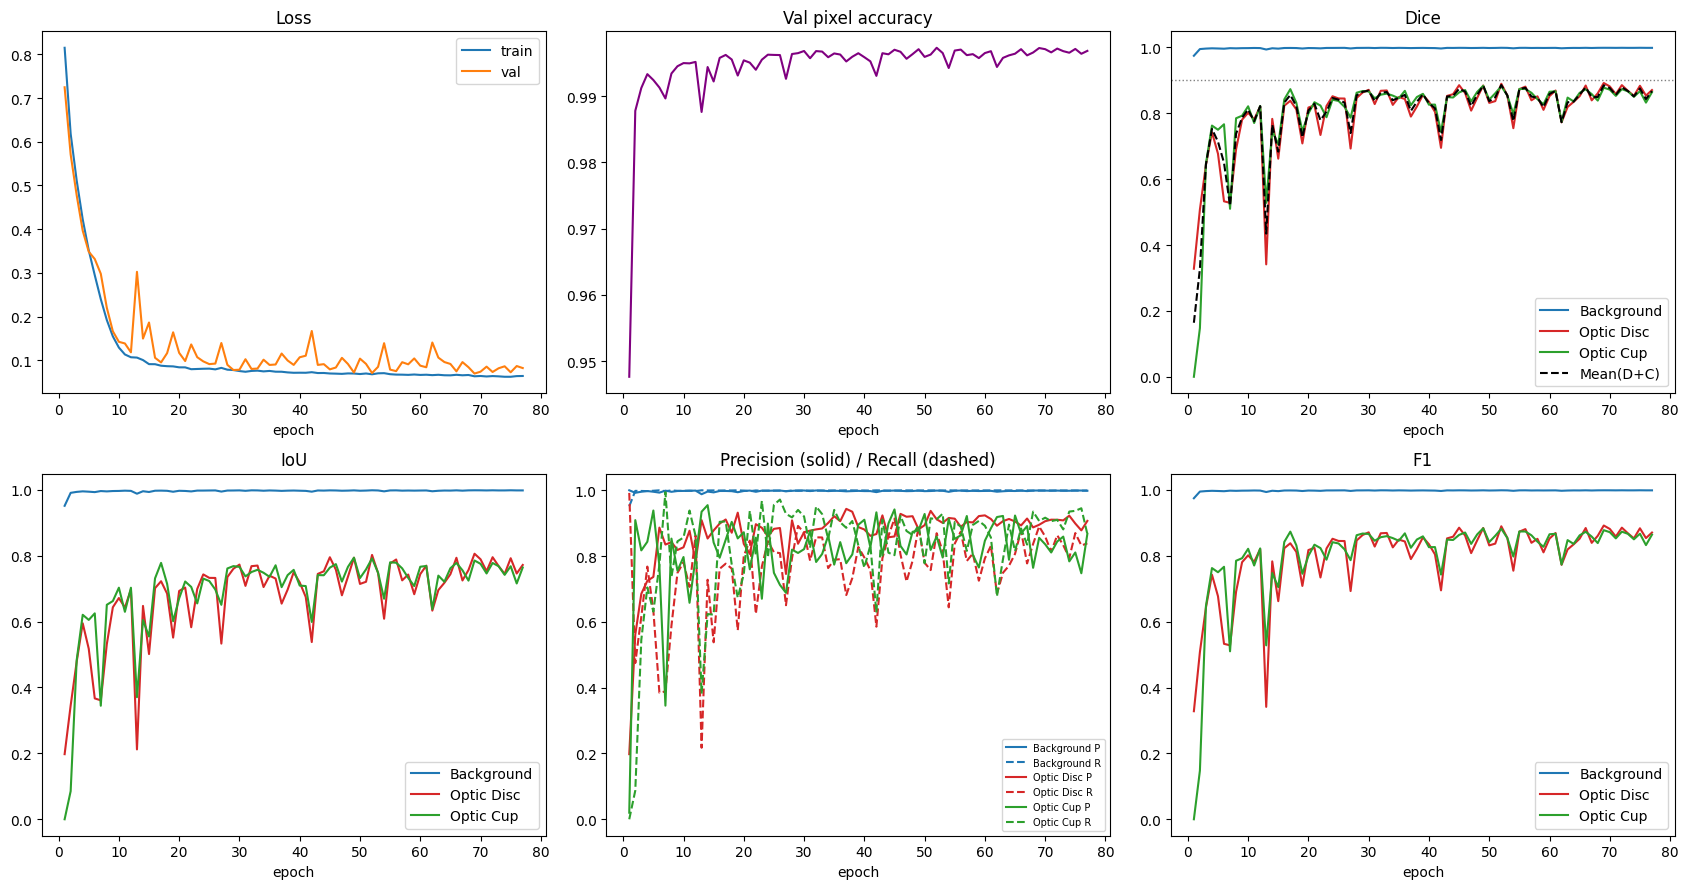

In [27]:
# ==== CELL 14 — Training curves (6 panels, same layout as your reports) ====
ep = range(1, len(history["train_loss"]) + 1)
dice = np.array(history["dice"]); iou = np.array(history["iou"])
prec = np.array(history["precision"]); rec = np.array(history["recall"]); f1 = np.array(history["f1"])
names = ["Background", "Optic Disc", "Optic Cup"]; cols = ["#1f77b4", "#d62728", "#2ca02c"]

fig, ax = plt.subplots(2, 3, figsize=(17, 9))
ax[0,0].plot(ep, history["train_loss"], label="train"); ax[0,0].plot(ep, history["val_loss"], label="val")
ax[0,0].set_title("Loss"); ax[0,0].legend(); ax[0,0].set_xlabel("epoch")

ax[0,1].plot(ep, history["val_acc"], color="purple"); ax[0,1].set_title("Val pixel accuracy"); ax[0,1].set_xlabel("epoch")

for c in range(3): ax[0,2].plot(ep, dice[:,c], label=names[c], color=cols[c])
ax[0,2].plot(ep, history["mean_dc"], "k--", label="Mean(D+C)")
ax[0,2].axhline(0.90, color="gray", ls=":", lw=1); ax[0,2].set_title("Dice"); ax[0,2].legend(); ax[0,2].set_xlabel("epoch")

for c in range(3): ax[1,0].plot(ep, iou[:,c], label=names[c], color=cols[c])
ax[1,0].set_title("IoU"); ax[1,0].legend(); ax[1,0].set_xlabel("epoch")

for c in range(3):
    ax[1,1].plot(ep, prec[:,c], color=cols[c], label=names[c]+" P")
    ax[1,1].plot(ep, rec[:,c],  color=cols[c], ls="--", label=names[c]+" R")
ax[1,1].set_title("Precision (solid) / Recall (dashed)"); ax[1,1].legend(fontsize=7); ax[1,1].set_xlabel("epoch")

for c in range(3): ax[1,2].plot(ep, f1[:,c], label=names[c], color=cols[c])
ax[1,2].set_title("F1"); ax[1,2].legend(); ax[1,2].set_xlabel("epoch")

plt.tight_layout(); plt.savefig(os.path.join(cfg.OUT_DIR, "training_curves.png"), dpi=120); plt.show()


In [28]:
# ==== CELL 15 — Anatomical post-processing ====
# The cup is ALWAYS inside the disc. The raw model predicts classes independently,
# so we (1) keep only the largest connected component per structure to kill speckle,
# (2) fill the disc, and (3) force every cup pixel to lie inside the disc.
# Cheap, no retraining, and directly targets the cup boundary errors.
def keep_largest(binary):
    if binary.sum() == 0: return binary
    lab, n = ndimage.label(binary)
    if n <= 1: return binary
    sizes = ndimage.sum(np.ones_like(lab), lab, range(1, n + 1))
    return lab == (int(np.argmax(sizes)) + 1)

def postprocess(pred):
    """pred: HxW int in {0,1,2} -> cleaned HxW int."""
    disc = keep_largest(pred == 1)
    cup  = keep_largest(pred == 2)
    disc_full = ndimage.binary_fill_holes(disc | cup)   # full optic disc = rim + cup
    cup = cup & disc_full                                # cup must be inside the disc
    res = np.zeros_like(pred)
    res[disc_full] = 1
    res[cup] = 2
    return res.astype(np.uint8)

print("Post-processing ready (largest-component + cup-inside-disc).")


Post-processing ready (largest-component + cup-inside-disc).


In [29]:
# ==== CELL 16 — Test-Time Augmentation (average softmax over flips) ====
@torch.no_grad()
def predict_probs(imgs, use_tta=True):
    """imgs: (B,3,H,W) on DEVICE -> averaged softmax probabilities (B,C,H,W)."""
    model.eval()
    flips = [lambda t: t,
             lambda t: torch.flip(t, dims=[3]),   # horizontal
             lambda t: torch.flip(t, dims=[2]),   # vertical
             lambda t: torch.flip(t, dims=[2, 3])]# both
    ops = flips if use_tta else flips[:1]
    probs = 0
    for f in ops:
        with autocast(enabled=cfg.USE_AMP):
            logits = model(f(imgs))
        p = F.softmax(logits.float(), dim=1)
        probs = probs + f(p)   # flips are self-inverse -> re-apply to align back
    return probs / len(ops)

print("TTA inference ready (", 4 if cfg.USE_TTA else 1, "views ).")


TTA inference ready ( 4 views ).


In [31]:
# ==== CELL 17 — Final test-set evaluation (Raw vs +TTA vs +TTA+PostProc) ====
# Loads the best checkpoint, then reports the full metric table for three settings so
# you can see exactly how much TTA and post-processing add on top of the raw model.
ckpt = torch.load(cfg.CKPT_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt["model"])
print(f"Loaded best checkpoint from epoch {ckpt['epoch']} (val MeanDC={ckpt['val_mean_dc']:.4f})\n")

def evaluate_test(use_tta, use_pp):
    agg = {k: np.zeros(cfg.NUM_CLASSES) for k in ["dice","iou","precision","recall","f1"]}
    acc_sum, n = 0.0, 0
    hd_disc, hd_cup = [], []
    for imgs, masks in test_loader:
        imgs = imgs.to(DEVICE)
        probs = predict_probs(imgs, use_tta=use_tta)             # (B,C,H,W)
        preds = probs.argmax(1).cpu().numpy()
        m_np = masks.numpy()
        for b in range(preds.shape[0]):
            p = postprocess(preds[b]) if use_pp else preds[b]
            pt = torch.from_numpy(np.asarray(p, dtype=np.int64))[None]      # one_hot needs int64
            gt = torch.from_numpy(np.asarray(m_np[b], dtype=np.int64))[None]
            met = compute_all_metrics(F.one_hot(pt, cfg.NUM_CLASSES).permute(0,3,1,2).float(), gt, cfg.NUM_CLASSES)
            for k in agg: agg[k] += np.array(met[k])
            acc_sum += met["accuracy"]; n += 1
            hd_disc.append(hd95_binary(p==1, m_np[b]==1))
            hd_cup.append(hd95_binary(p==2, m_np[b]==2))
    for k in agg: agg[k] /= n
    acc = acc_sum / n
    mean_dc = (agg["dice"][1] + agg["dice"][2]) / 2.0
    return agg, acc, mean_dc, np.nanmean(hd_disc), np.nanmean(hd_cup)

settings = [("Raw", False, False)]
if cfg.USE_TTA: settings.append(("+TTA", True, False))
if cfg.USE_TTA and cfg.USE_POSTPROC: settings.append(("+TTA +PostProc", True, True))
elif cfg.USE_POSTPROC: settings.append(("+PostProc", False, True))

print(f"{'Setting':16s} | {'Disc':>6s} {'Cup':>6s} {'Mean(D+C)':>10s} | {'Acc':>6s} | {'HD95 disc':>9s} {'HD95 cup':>8s}")
print("-"*80)
results = {}
for name, tta, pp in settings:
    agg, acc, mdc, hdd, hdc = evaluate_test(tta, pp)
    results[name] = (agg, acc, mdc, hdd, hdc)
    print(f"{name:16s} | {agg['dice'][1]:6.4f} {agg['dice'][2]:6.4f} {mdc:10.4f} | {acc:6.4f} | {hdd:9.2f} {hdc:8.2f}")

# full per-class table for the best (last) setting
best_name = settings[-1][0]; agg, acc, mdc, hdd, hdc = results[best_name]
print("\n=== Full per-class metrics ("+best_name+") ===")
print(f"{'Class':12s} {'Dice':>7s} {'IoU':>7s} {'Prec':>7s} {'Recall':>7s} {'F1':>7s}")
for c, nm in enumerate(["Background","Optic Disc","Optic Cup"]):
    print(f"{nm:12s} {agg['dice'][c]:7.4f} {agg['iou'][c]:7.4f} {agg['precision'][c]:7.4f} {agg['recall'][c]:7.4f} {agg['f1'][c]:7.4f}")
print(f"{'Mean(D+C)':12s} {mdc:7.4f} {(agg['iou'][1]+agg['iou'][2])/2:7.4f}")
print(f"\nTest pixel accuracy: {acc:.4f}")
print("TARGET 0.90 " + ("REACHED ✅" if mdc >= 0.90 else f"-> {0.90-mdc:+.4f} to go"))

# save metrics to CSV
import csv
with open(os.path.join(cfg.OUT_DIR, "test_metrics.csv"), "w", newline="") as fcsv:
    w = csv.writer(fcsv); w.writerow(["setting","disc_dice","cup_dice","mean_dc","accuracy","hd95_disc","hd95_cup"])
    for nm,(a,ac,md,hd,hc) in results.items():
        w.writerow([nm, a['dice'][1], a['dice'][2], md, ac, hd, hc])
print("Saved:", os.path.join(cfg.OUT_DIR, "test_metrics.csv"))


Loaded best checkpoint from epoch 52 (val MeanDC=0.8860)

Setting          |   Disc    Cup  Mean(D+C) |    Acc | HD95 disc HD95 cup
--------------------------------------------------------------------------------
Raw              | 0.8711 0.8557     0.8634 | 0.9970 |      5.00     4.22
+TTA             | 0.8784 0.8603     0.8694 | 0.9973 |      3.77     3.40
+TTA +PostProc   | 0.8785 0.8603     0.8694 | 0.9973 |      3.03     3.40

=== Full per-class metrics (+TTA +PostProc) ===
Class           Dice     IoU    Prec  Recall      F1
Background    0.9992  0.9984  0.9995  0.9989  0.9992
Optic Disc    0.8785  0.7886  0.8767  0.8867  0.8785
Optic Cup     0.8603  0.7605  0.8119  0.9370  0.8603
Mean(D+C)     0.8694  0.7746

Test pixel accuracy: 0.9973
TARGET 0.90 -> +0.0306 to go
Saved: /kaggle/working/test_metrics.csv


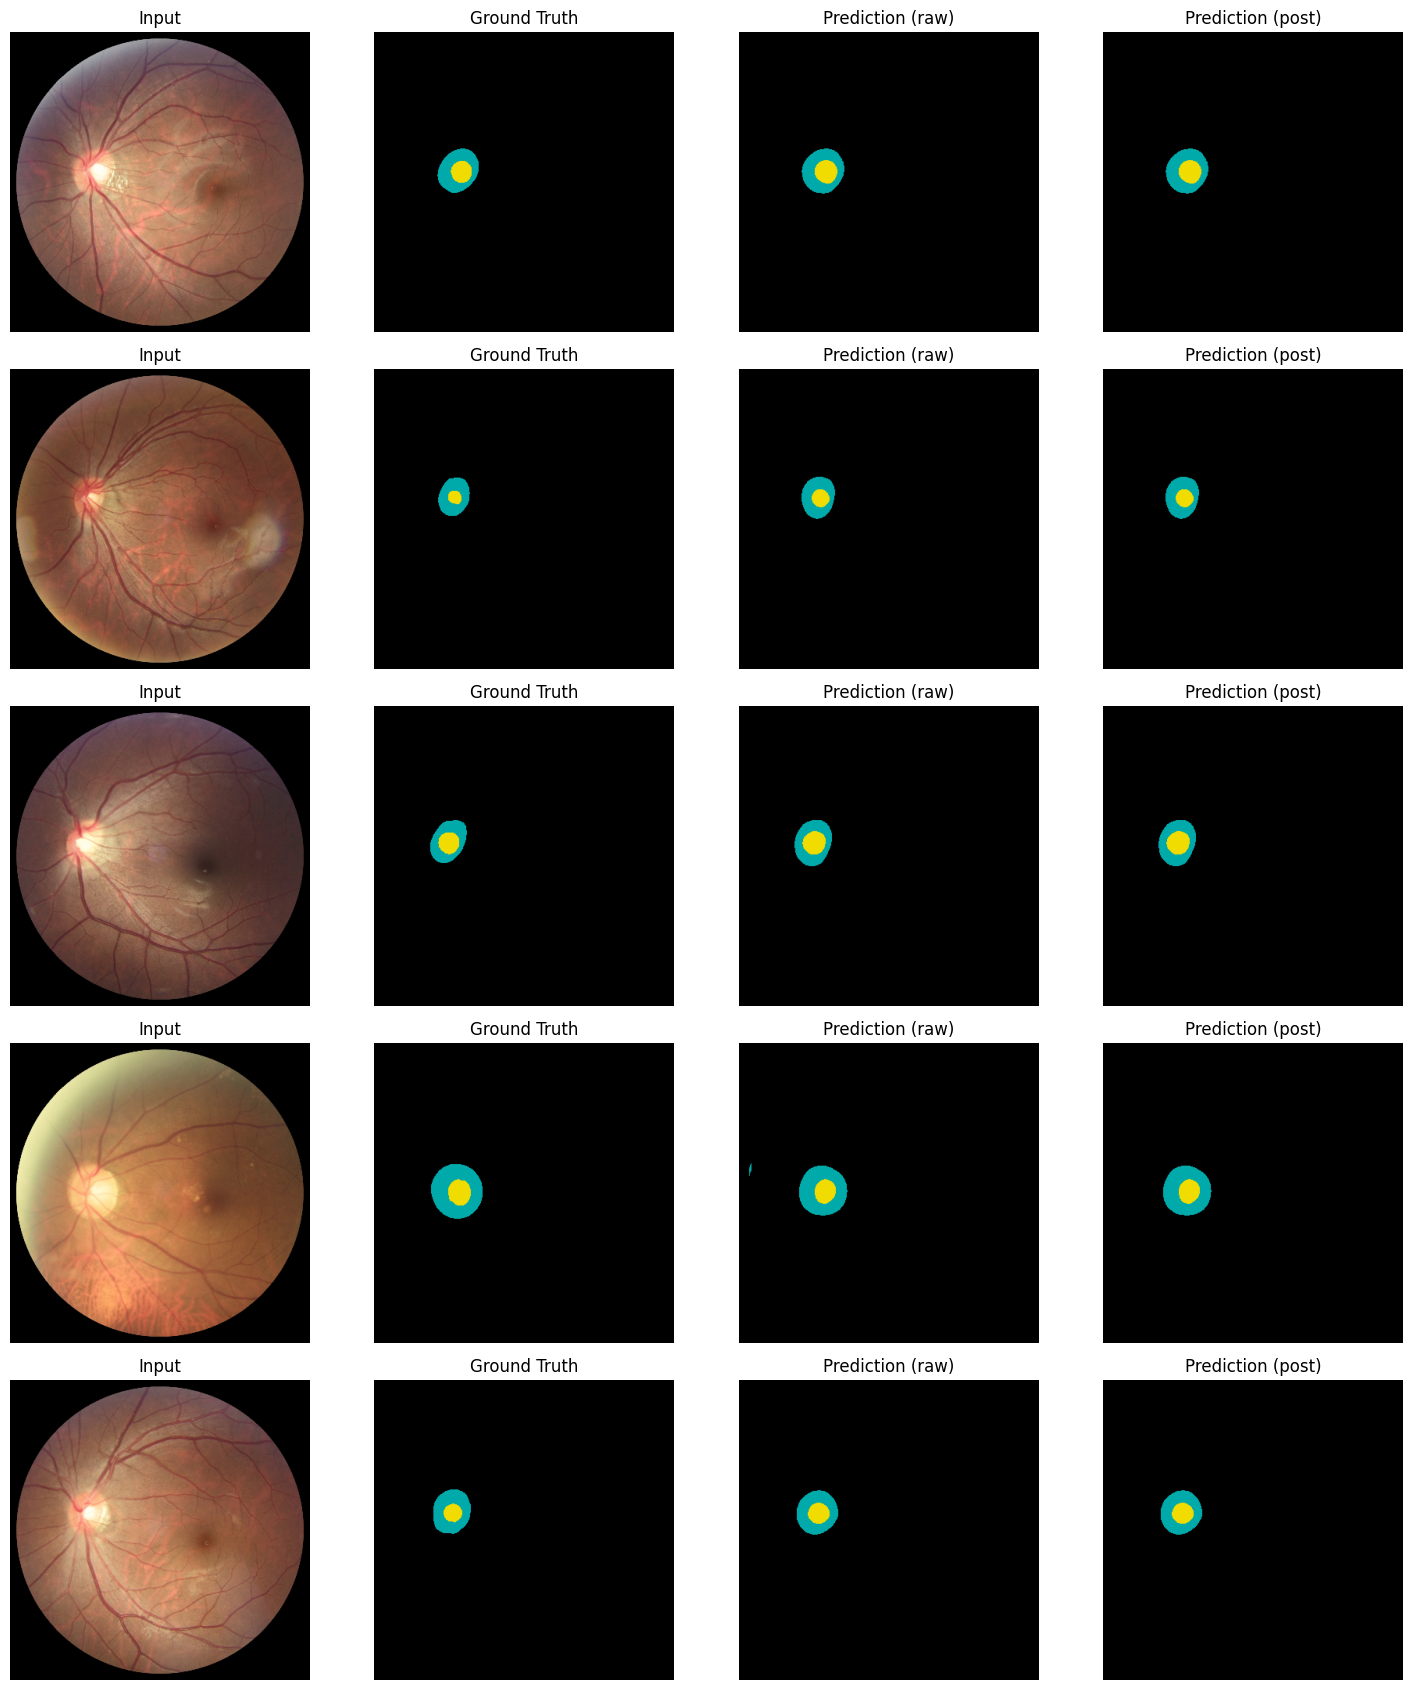

teal = optic disc, yellow = optic cup


In [32]:
# ==== CELL 18 — Qualitative predictions (Input / GT / Raw pred / Post-processed) ====
model.eval()
n_show = 5
shown = 0
fig, ax = plt.subplots(n_show, 4, figsize=(15, 3.4*n_show))
for imgs, masks in test_loader:
    imgs_d = imgs.to(DEVICE)
    probs = predict_probs(imgs_d, use_tta=cfg.USE_TTA)
    preds = probs.argmax(1).cpu().numpy()
    for b in range(imgs.shape[0]):
        if shown >= n_show: break
        raw = preds[b]; pp = postprocess(raw)
        ax[shown,0].imshow(denorm(imgs[b]));            ax[shown,0].set_title("Input");            ax[shown,0].axis("off")
        ax[shown,1].imshow(colorize(masks[b].numpy())); ax[shown,1].set_title("Ground Truth");     ax[shown,1].axis("off")
        ax[shown,2].imshow(colorize(raw));              ax[shown,2].set_title("Prediction (raw)"); ax[shown,2].axis("off")
        ax[shown,3].imshow(colorize(pp));               ax[shown,3].set_title("Prediction (post)");ax[shown,3].axis("off")
        shown += 1
    if shown >= n_show: break
plt.tight_layout(); plt.savefig(os.path.join(cfg.OUT_DIR, "qualitative_predictions.png"), dpi=120); plt.show()
print("teal = optic disc, yellow = optic cup")


In [33]:
# ==== CELL 19 — Run summary ====
print("="*64)
print(" U-KAN 3-class REFUGE — RUN SUMMARY")
print("="*64)
print(f" Image size          : {cfg.IMG_SIZE}x{cfg.IMG_SIZE}")
print(f" Params              : {sum(p.numel() for p in model.parameters()):,}")
print(f" Best val Mean(D+C)  : {best_dc:.4f} @ epoch {best_epoch}")
bn = settings[-1][0]; a, ac, md, hd, hc = results[bn]
print(f" Test  Mean(D+C)     : {md:.4f}  [{bn}]  (Disc {a['dice'][1]:.4f}, Cup {a['dice'][2]:.4f})")
print(f" Test  accuracy      : {ac:.4f}")
print(f" 0.90 target         : {'REACHED ✅' if md>=0.90 else f'{0.90-md:+.4f} to go'}")
print("-"*64)
print(" Artifacts saved to /kaggle/working:")
print("   ukan_refuge_best.pth, training_curves.png,")
print("   qualitative_predictions.png, test_metrics.csv")
print("="*64)
print("\nIf cup Dice is still the ceiling, next levers: raise CLASS_WEIGHTS cup to 2.5-3.0,")
print("increase TVERSKY_BETA to 0.8, bump IMG_SIZE to 512, or train a 2nd-stage cup model")
print("on the cropped disc ROI, then ensemble with your U-Net / W-Net.")


 U-KAN 3-class REFUGE — RUN SUMMARY
 Image size          : 384x384
 Params              : 25,359,331
 Best val Mean(D+C)  : 0.8860 @ epoch 52
 Test  Mean(D+C)     : 0.8694  [+TTA +PostProc]  (Disc 0.8785, Cup 0.8603)
 Test  accuracy      : 0.9973
 0.90 target         : +0.0306 to go
----------------------------------------------------------------
 Artifacts saved to /kaggle/working:
   ukan_refuge_best.pth, training_curves.png,
   qualitative_predictions.png, test_metrics.csv

If cup Dice is still the ceiling, next levers: raise CLASS_WEIGHTS cup to 2.5-3.0,
increase TVERSKY_BETA to 0.8, bump IMG_SIZE to 512, or train a 2nd-stage cup model
on the cropped disc ROI, then ensemble with your U-Net / W-Net.
